In [1]:
import numpy as np
import pandas as pd
import os
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import probplot, mannwhitneyu
from IPython.display import display as dsp
%matplotlib inline
os.chdir('..')

df = pd.read_csv("./data/raw/train.csv")
from functions.eda_functions import NormalDistributionTest, list_missing_values
from functions.featuresCorrelation import Features_correlations

In [2]:
list_missing_values(df)
testNormalize = NormalDistributionTest(df)
testNormalize.jarque_bera(['PoolArea'])

,missing counts,percentage(%)
PoolQC,1453,99.52
MiscFeature,1406,96.30
Alley,1369,93.77
Fence,1179,80.75
MasVnrType,872,59.73
FireplaceQu,690,47.26
LotFrontage,259,17.74
GarageType,81,5.55
GarageYrBlt,81,5.55
GarageFinish,81,5.55


,name_feature,jb_stat,p_value,skewness,kurtosis,normal,evidence_non_normality,interpretacion
0,PoolArea,3.065038e+06,0.0,14.813135,222.500507,False,True,No normal


In [3]:
df_numeric = df.select_dtypes(include=[np.number]).dropna().drop(columns=['Id'])
matrix_corr = df_numeric.corr(method='pearson').round(2).apply(lambda x: x * 100)
matrix_corr



,MSSubClass,LotFrontage,LotArea,OverallQual,OverallCond,YearBuilt,YearRemodAdd,MasVnrArea,BsmtFinSF1,BsmtFinSF2,...,WoodDeckSF,OpenPorchSF,EnclosedPorch,3SsnPorch,ScreenPorch,PoolArea,MiscVal,MoSold,YrSold,SalePrice
MSSubClass,100.0,-39.0,-20.0,3.0,-9.0,3.0,1.0,4.0,-7.0,-8.0,...,-2.0,0.0,-2.0,-4.0,-2.0,0.0,-4.0,-3.0,-1.0,-9.0
LotFrontage,-39.0,100.0,42.0,24.0,-5.0,11.0,9.0,19.0,24.0,5.0,...,8.0,16.0,1.0,7.0,4.0,21.0,0.0,2.0,1.0,34.0
LotArea,-20.0,42.0,100.0,17.0,-3.0,3.0,3.0,11.0,23.0,14.0,...,13.0,10.0,-2.0,1.0,7.0,11.0,1.0,1.0,-1.0,30.0
OverallQual,3.0,24.0,17.0,100.0,-16.0,59.0,57.0,42.0,25.0,-7.0,...,28.0,34.0,-14.0,2.0,6.0,8.0,-6.0,8.0,-1.0,80.0
OverallCond,-9.0,-5.0,-3.0,-16.0,100.0,-43.0,4.0,-17.0,-5.0,4.0,...,-1.0,-8.0,6.0,-1.0,9.0,-2.0,12.0,-1.0,4.0,-12.0
YearBuilt,3.0,11.0,3.0,59.0,-43.0,100.0,62.0,33.0,24.0,-5.0,...,24.0,24.0,-39.0,3.0,-6.0,1.0,-10.0,1.0,-0.0,53.0
YearRemodAdd,1.0,9.0,3.0,57.0,4.0,62.0,100.0,19.0,12.0,-6.0,...,24.0,26.0,-21.0,3.0,-3.0,2.0,-4.0,3.0,4.0,52.0
MasVnrArea,4.0,19.0,11.0,42.0,-17.0,33.0,19.0,100.0,29.0,-8.0,...,17.0,13.0,-12.0,2.0,5.0,2.0,-5.0,2.0,-2.0,49.0
BsmtFinSF1,-7.0,24.0,23.0,25.0,-5.0,24.0,12.0,29.0,100.0,-4.0,...,21.0,13.0,-11.0,2.0,6.0,19.0,0.0,-2.0,1.0,39.0
BsmtFinSF2,-8.0,5.0,14.0,-7.0,4.0,-5.0,-6.0,-8.0,-4.0,100.0,...,3.0,1.0,5.0,-3.0,7.0,6.0,1.0,-4.0,4.0,-3.0


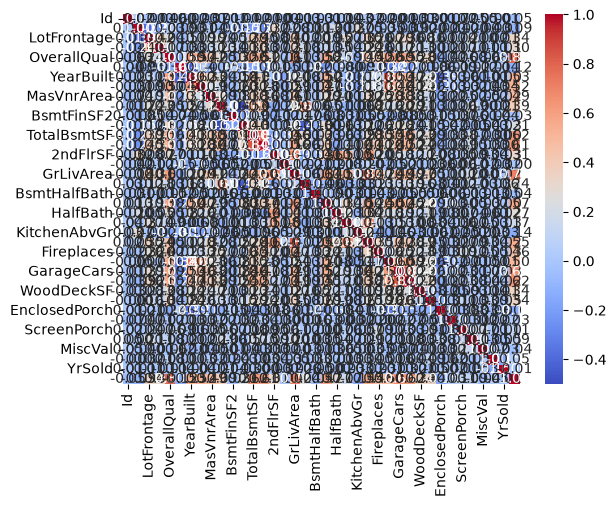

In [6]:
fc = Features_correlations(df)
#fc.spearman_correlation_and_plot("PoolArea", "TotRmsAbvGrd")
matrix = fc.calculate_pearson_matrix()
sns.heatmap(matrix, annot=True, cmap="coolwarm", fmt=".2f")
plt.show()